In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import tensorflow as tf
from tensorflow.keras.models import load_model

In [ ]:
# Load CSV file
test_df = pd.read_csv("C:/Users/harma/OneDrive/Desktop/project2/data2/test.csv")

# Add .png extension to ID codes
test_df["id_code"] = test_df["id_code"].astype(str) + ".png"

# Convert to list
test_ids = test_df["id_code"].tolist()

In [18]:
test_df.head()

,id_code
0,00e4ddff966a.png
1,00f6c1be5a33.png
2,0a4e1a29ffff.png
3,0a09aa7356c0.png
4,0a09aa7356c0_aug_142.png


In [19]:
test_df.shape

(2000, 1)

In [20]:
test_ids

['00e4ddff966a.png',
 '00f6c1be5a33.png',
 '0a4e1a29ffff.png',
 '0a09aa7356c0.png',
 '0a09aa7356c0_aug_142.png',
 '0a09aa7356c0_aug_390.png',
 '0a9ec1e99ce4.png',
 '0a38b552372d.png',
 '0a61bddab956.png',
 '0a61bddab956_aug_80.png',
 '0a61bddab956_aug_306.png',
 '0a74c92e287c.png',
 '0a85a1e8f9e9.png',
 '0a902c80d5da.png',
 '0a3202889f4d.png',
 '0a1076183736.png',
 '0abf0c485f66.png',
 '0ac436400db4.png',
 '0ad7f631dedb.png',
 '0ada12c0e78f.png',
 '0ada12c0e78f_aug_219.png',
 '0ada12c0e78f_aug_361.png',
 '0ae2dd2e09ea.png',
 '0af296d2f04a.png',
 '0afbeeef0ff7.png',
 '0afdfe5f422c.png',
 '0b00f8a77510.png',
 '0b2ea8f268cf.png',
 '0b3efe669365.png',
 '0b8bdec9d869.png',
 '0b64a0a06f9a.png',
 '0babc12807b2.png',
 '0bf37ca3156a.png',
 '0bf37ca3156a_aug_87.png',
 '0bf37ca3156a_aug_111.png',
 '0bf37ca3156a_aug_365.png',
 '0bf37ca3156a_aug_388.png',
 '0bf37ca3156a_aug_417.png',
 '0c2e2369dfff.png',
 '0c2e2369dfff_aug_223.png',
 '0c7e82daf5a0.png',
 '0c43c79e8cfb.png',
 '0c55d58bebaf.png',
 '0

In [ ]:
test_image_path = 'C:/Users/harma/OneDrive/Desktop/project2/data2/test.csv'

In [22]:
def load_and_preprocess_images(image_ids, image_folder, target_size=(240, 240)):
    images = []
    valid_ids = []

    for img_id in image_ids:
        img_path = os.path.join(image_folder, img_id)
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, target_size)
            img = img / 255.0  # Normalize
            images.append(img)
            valid_ids.append(img_id)  # Keep track of successfully loaded IDs

    return np.array(images), valid_ids

In [23]:
print(f"📂 image_folder: {test_image_path} | Type: {type(test_image_path)}")

📂 image_folder: C:/Users/harma/OneDrive/Desktop/project2/data2/test_new/Book1.csv | Type: <class 'str'>


In [24]:
def classify_and_save(model_path, test_ids, test_folder, output_file, class_label, actual_label, binary=False):
    print(f"\nLoading model: {model_path}")
    model = load_model(model_path, compile=False)

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    print(f"Processing {len(test_ids)} images...")

    # Load and preprocess test images
    test_images, valid_ids = load_and_preprocess_images(test_ids, test_folder)

    # Check if images were loaded
    print(f"Successfully loaded {len(test_images)} images.")

    if len(test_images) == 0:
        print("No images to process. Skipping this step.")
        return pd.DataFrame()  # Return empty DataFrame if no valid images

    # Predict using the model
    predictions = model.predict(test_images)
    if binary:  # Use for binary classification
        predicted_labels = (predictions > 0.5).astype(int).flatten()
    else:       # Use for multi-class classification
        predicted_labels = np.argmax(predictions, axis=1)

    # Print some sample predictions
    print(f"Sample Predictions: {predicted_labels[:10]}")

    # Select images classified as the given class_label
    classified_ids = [valid_ids[i] for i in range(len(predicted_labels)) if predicted_labels[i] == class_label]

    # Check if any images were classified
    print(f"Number of images classified as {class_label}: {len(classified_ids)}")

    # Save results to DataFrame
    df_results = pd.DataFrame({"ID Code": classified_ids, "Predicted Label": actual_label})
    df_results.to_excel(output_file, index=False)

    print(f"Saved {len(classified_ids)} classified images to {output_file}")

    return df_results

In [ ]:
# Define test data file and model paths


test_data_file = "C:/Users/harma/OneDrive/Desktop/project2/data2/test.csv"
test_image_folder = 'C:/Users/harma/OneDrive/Desktop/project2/data2/test_images'

# Model paths
model_4 = "C:/Users/harma/OneDrive/Desktop/project2/data2/best_model_m.h5"
model_3 = "C:/Users/harma/OneDrive/Desktop/project2/data2/best_model_qt.h5"
model_2 = "C:/Users/harma/OneDrive/Desktop/project2/data2/best_model_t.h5"
model_1 = "C:/Users/harma/OneDrive/Desktop/project2/data2/best_model_b.h5"

# First, classify label 2
df_label_2 = classify_and_save(model_4, test_ids, test_image_folder, "classified_label_2.xlsx", class_label=1, actual_label=2, binary=True)
remaining_ids = list(set(test_ids) - set(df_label_2["ID Code"]))

# Predict label 1 (model 3)
df_label_1 = classify_and_save(model_3, remaining_ids, test_image_folder, "classified_label_1.xlsx", class_label=1, actual_label=1, binary=True)
remaining_ids = list(set(remaining_ids) - set(df_label_1["ID Code"]))

# Predict label 4 (model 2)
df_label_4 = classify_and_save(model_2, remaining_ids, test_image_folder, "classified_label_4.xlsx", class_label=1, actual_label=4, binary=True)
remaining_ids = list(set(remaining_ids) - set(df_label_4["ID Code"]))

# Predict label 3 (model 1 - binary 0=0, 1=3)
df_label_3 = classify_and_save(model_1, remaining_ids, test_image_folder, "classified_label_3.xlsx", class_label=1, actual_label=3, binary=True)
remaining_ids = list(set(remaining_ids) - set(df_label_3["ID Code"]))

# Remaining are label 0
df_label_0 = pd.DataFrame({"ID Code": remaining_ids, "Predicted Label": 0})
df_label_0.to_excel("classified_label_0.xlsx", index=False)
print(f"Label 0 assigned to {len(remaining_ids)} remaining images.")



Loading model: C:/Users/harma/OneDrive/Desktop/project2/data2/best_model_m.h5
Processing 2000 images...
Successfully loaded 2000 images.
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 460ms/step
Sample Predictions: [0 0 0 0 0 0 0 0 0 0]
Number of images classified as 1: 63
Saved 63 classified images to classified_label_2.xlsx

Loading model: C:/Users/harma/OneDrive/Desktop/project2/data2/best_model_qt.h5
Processing 1937 images...
Successfully loaded 1937 images.
61/61 ━━━━━━━━━━━━━━━━━━━━ 30s 462ms/step
Sample Predictions: [1 0 0 1 0 1 1 0 0 1]
Number of images classified as 1: 1154
Saved 1154 classified images to classified_label_1.xlsx

Loading model: C:/Users/harma/OneDrive/Desktop/project2/data2/best_model_t.h5
Processing 783 images...
Successfully loaded 783 images.
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 503ms/step
Sample Predictions: [1 1 1 1 0 0 1 1 0 0]
Number of images classified as 1: 216
Saved 216 classified images to classified_label_4.xlsx

Loading model: C:/Users/harma/OneDrive/Desktop/project2

In [26]:
df = pd.read_excel("C:/Users/harma/OneDrive/Desktop/project2/data2/classified_label_2.xlsx")
print(df)

             ID Code  Predicted Label
0   003f0afdcd15.png                2
1   033cdbbbdfaa.png                2
2   0654cdd3c01a.png                2
3   0737dfb0a164.png                2
4   0aebb1b2aef1.png                2
..               ...              ...
92  f756b1c4c52b.png                2
93  fc3935afc788.png                2
94  fda8612fcc8c.png                2
95  fe190d618acf.png                2
96  fe920e47b72d.png                2

[97 rows x 2 columns]


In [27]:
df = pd.read_excel("C:/Users/harma/OneDrive/Desktop/project2/data2/classified_label_1.xlsx")
print(df)

               ID Code  Predicted Label
0     2f042d9c1376.png                1
1     3ef3056cc3d0.png                1
2     8d955a3d9286.png                1
3     bc2a4b1c45b0.png                1
4     1d1539c0fb03.png                1
...                ...              ...
1474  c0f949e900cc.png                1
1475  dbf67b9638cd.png                1
1476  25217ad0dfae.png                1
1477  51f0bf8f1544.png                1
1478  ee544d980b5e.png                1

[1479 rows x 2 columns]


In [28]:
df = pd.read_excel("C:/Users/harma/OneDrive/Desktop/project2/data2/classified_label_4.xlsx")
print(df)

              ID Code  Predicted Label
0    3c21f8d1fa62.png                4
1    437fa52cb1cb.png                4
2    0ba16f32500e.png                4
3    d099f9ee17f2.png                4
4    3b9ee705c750.png                4
..                ...              ...
145  760f9f1cf5c2.png                4
146  6f43a3d1ed0a.png                4
147  ee98121d0c5a.png                4
148  a07855461605.png                4
149  0a2b5e1a0be8.png                4

[150 rows x 2 columns]


In [29]:
df = pd.read_excel("C:/Users/harma/OneDrive/Desktop/project2/data2/classified_label_3.xlsx")
print(df)

             ID Code  Predicted Label
0   c13e52ea958e.png                3
1   b78412d404fc.png                3
2   39f82967009b.png                3
3   e051148841ce.png                3
4   e57ddcade9b2.png                3
..               ...              ...
66  8571e10b7294.png                3
67  69bf0233198e.png                3
68  0cad3584e761.png                3
69  badf9d11fe77.png                3
70  5110fe0bf9cb.png                3

[71 rows x 2 columns]


In [30]:
df = pd.read_excel("C:/Users/harma/OneDrive/Desktop/project2/data2/classified_label_0.xlsx")
print(df)

              ID Code  Predicted Label
0    95c3558dc279.png                0
1    16ae04d67de3.png                0
2    7959bb5d9fa2.png                0
3    f8aa9af6ca63.png                0
4    f1541578ba01.png                0
..                ...              ...
126  bef30368d78d.png                0
127  10407824638c.png                0
128  f5b4f7bc69e7.png                0
129  9375f39522ab.png                0
130  b90a9ac76003.png                0

[131 rows x 2 columns]


In [31]:
# List of Excel file paths (update these to match your file names/paths)
excel_files = [
    'C:/Users/harma/OneDrive/Desktop/project2/data2/classified_label_0.xlsx',
    'C:/Users/harma/OneDrive/Desktop/project2/data2/classified_label_1.xlsx',
    'C:/Users/harma/OneDrive/Desktop/project2/data2/classified_label_2.xlsx',
    'C:/Users/harma/OneDrive/Desktop/project2/data2/classified_label_3.xlsx',
    'C:/Users/harma/OneDrive/Desktop/project2/data2/classified_label_4.xlsx'
]

# List to store DataFrames
dfs = []

# Read and store each Excel file's contents
for file in excel_files:
    df = pd.read_excel(file)  # If sheets are named, you can add sheet_name='Sheet1'
    dfs.append(df[['ID Code', 'Predicted Label']])  # Ensures only relevant columns are kept

# Combine all DataFrames into one
combined_df = pd.concat(dfs, ignore_index=True)

# Optional: Drop duplicates if needed
# combined_df = combined_df.drop_duplicates(subset='id_code')

# Save the combined result to a new Excel file
combined_df.to_excel('combined_predictions.xlsx', index=False)

print("All files combined into 'combined_predictions.xlsx'")

All files combined into 'combined_predictions.xlsx'


In [32]:
df = pd.read_excel("C:/Users/harma/OneDrive/Desktop/project2/data2/combined_predictions.xlsx")
print(df)

               ID Code  Predicted Label
0     95c3558dc279.png                0
1     16ae04d67de3.png                0
2     7959bb5d9fa2.png                0
3     f8aa9af6ca63.png                0
4     f1541578ba01.png                0
...                ...              ...
1923  760f9f1cf5c2.png                4
1924  6f43a3d1ed0a.png                4
1925  ee98121d0c5a.png                4
1926  a07855461605.png                4
1927  0a2b5e1a0be8.png                4

[1928 rows x 2 columns]


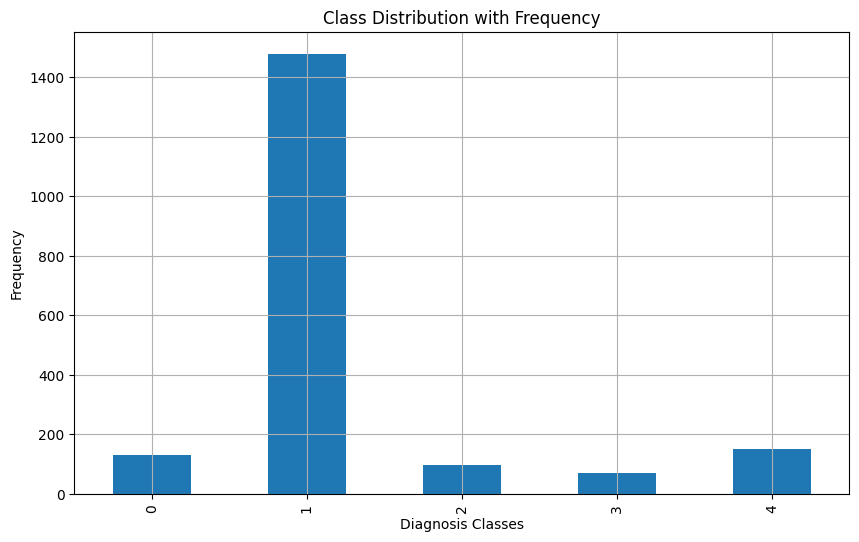

In [33]:
df["Predicted Label"].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 6),
    grid=True
)

plt.title('Class Distribution with Frequency')
plt.xlabel('Diagnosis Classes')
plt.ylabel('Frequency')
plt.show()
